# FreightAI: Logistics Decision-Support System

This project builds a machine learning-powered tool to estimate shipment performance and risk using freight data.


## Objective
This project develops a decision-support system to help logistics professionals evaluate shipments before execution.

The system combines:
- Regression to estimate transit time
- Classification to predict shipment risk
- An AI layer to generate explanations and recommendations



## Key Idea
Transform historical freight data into actionable insights that support proactive logistics planning.

# Data Source

We use the Freight Analysis Framework (FAF) dataset, which includes:
- Origin–destination freight flows
- Transportation modes
- Freight volume and value

We combine:
- State-level dataset (primary modeling)
- Regional dataset (feature enrichment)

## Data Loading

In [ ]:
# Mount Google Drive to access data files
from google.colab import drive
drive.mount('/content/drive')

# After running this notebook, the model export cell below will
# download reg_model.pkl and clf_model.pkl — place these in your
# freightai_v3/data/ folder to integrate with the Streamlit dashboard.


Mounted at /content/drive


In [ ]:
import pandas as pd

state_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/FAF4.4_State.csv')
regional_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/FAF4_Regional.csv')

print("State Data Shape:", state_df.shape)
print("Regional Data Shape:", regional_df.shape)

State Data Shape: (550321, 42)
Regional Data Shape: (1660972, 42)


## Data Inspection

We examine the structure, columns, and summary statistics to understand the dataset.

In [ ]:
state_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550321 entries, 0 to 550320
Data columns (total 42 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   fr_orig      218085 non-null  float64
 1   dms_orig     550321 non-null  int64  
 2   dms_dest     550321 non-null  int64  
 3   fr_dest      219434 non-null  float64
 4   fr_inmode    218085 non-null  float64
 5   dms_mode     550321 non-null  int64  
 6   fr_outmode   219434 non-null  float64
 7   sctg2        550321 non-null  int64  
 8   trade_type   550321 non-null  int64  
 9   tons_2012    550321 non-null  float64
 10  tons_2013    550321 non-null  float64
 11  tons_2014    550321 non-null  float64
 12  tons_2015    550321 non-null  float64
 13  tons_2020    550321 non-null  float64
 14  tons_2025    550321 non-null  float64
 15  tons_2030    550321 non-null  float64
 16  tons_2035    550321 non-null  float64
 17  tons_2040    550321 non-null  float64
 18  tons_2045    550321 non-

In [ ]:
state_df.head()

,fr_orig,dms_orig,dms_dest,fr_dest,fr_inmode,dms_mode,fr_outmode,sctg2,trade_type,tons_2012,...,tmiles_2015,tmiles_2020,tmiles_2025,tmiles_2030,tmiles_2035,tmiles_2040,tmiles_2045,curval_2013,curval_2014,curval_2015
0,NaN,1,1,NaN,NaN,1,NaN,1,1,3084.7678,...,204.8564,230.8865,254.3870,277.7117,305.7184,336.1778,351.9228,4273.0414,5156.8149,4713.9220
1,NaN,1,12,NaN,NaN,1,NaN,1,1,10.5060,...,4.4557,4.2213,4.0848,3.9862,3.8644,4.0277,4.3933,21.0003,23.9063,21.2444
2,NaN,1,13,NaN,NaN,1,NaN,1,1,97.4125,...,27.3168,26.4331,26.7289,27.8136,28.6019,28.5799,31.2815,147.2225,149.8771,131.5474
3,NaN,1,20,NaN,NaN,1,NaN,1,1,40.1150,...,29.6268,29.7992,28.4390,26.7350,24.9841,23.8533,25.2513,115.0118,101.3772,88.1043
4,NaN,1,22,NaN,NaN,1,NaN,1,1,23.3480,...,4.5342,4.5391,4.5167,4.5650,4.6830,4.7934,5.1410,34.9698,44.8126,40.8650


In [ ]:
print(state_df.columns)

Index(['fr_orig', 'dms_orig', 'dms_dest', 'fr_dest', 'fr_inmode', 'dms_mode',
       'fr_outmode', 'sctg2', 'trade_type', 'tons_2012', 'tons_2013',
       'tons_2014', 'tons_2015', 'tons_2020', 'tons_2025', 'tons_2030',
       'tons_2035', 'tons_2040', 'tons_2045', 'value_2012', 'value_2013',
       'value_2014', 'value_2015', 'value_2020', 'value_2025', 'value_2030',
       'value_2035', 'value_2040', 'value_2045', 'tmiles_2012', 'tmiles_2013',
       'tmiles_2014', 'tmiles_2015', 'tmiles_2020', 'tmiles_2025',
       'tmiles_2030', 'tmiles_2035', 'tmiles_2040', 'tmiles_2045',
       'curval_2013', 'curval_2014', 'curval_2015'],
      dtype='object')


# Feature Engineering

Since the dataset does not include transit time, we engineer it using:
- Distance (simulated)
- Freight volume
- Route congestion (regional data)

We also create:
- Risk classification (Low, Medium, High)

In [ ]:
import numpy as np

# Create route-level freight volume from regional data
route_volume = regional_df.groupby(['dms_orig', 'dms_dest'])['tons_2012'].sum().reset_index()
route_volume.rename(columns={'tons_2012': 'route_total_volume'}, inplace=True)

# Remove any existing route_total_volume columns from state_df before merging to avoid conflicts
# This handles cases where the cell might have been run multiple times or partially failed.
columns_to_drop = [col for col in state_df.columns if 'route_total_volume' in col]
state_df = state_df.drop(columns=columns_to_drop, errors='ignore')

# Merge into state dataset
state_df = state_df.merge(route_volume, on=['dms_orig', 'dms_dest'], how='left')

# Fill missing values (important)
state_df['route_total_volume'] = state_df['route_total_volume'].fillna(state_df['route_total_volume'].median())

# Feature Engineering (Improved)

# Distance
DISTANCES = {
    ("Los Angeles", "New York"): 2800,
    ("Chicago", "Miami"): 1400,
    ("Dallas", "Denver"): 800,
    ("Seattle", "Houston"): 2300,
    ("Los Angeles", "Chicago"): 2000,
    ("New York", "Miami"): 1300
}

distance = DISTANCES.get((origin, destination), 1500)

# Mode encoding
state_df['mode_encoded'] = state_df['dms_mode']

# Create congestion index FIRST (important)
state_df['congestion_index'] = np.log1p(state_df['route_total_volume'])

# Improved transit time (multi-factor)
state_df['transit_time'] = (
    state_df['distance'] / (45 + state_df['mode_encoded'] * 6) +
    state_df['congestion_index'] * 2 +
    np.log1p(state_df['tons_2012']) * 1.2 +
    np.random.normal(0, 2, len(state_df))
)

# Quick check
state_df[['distance', 'congestion_index', 'transit_time']].head()

,distance,congestion_index,transit_time
0,506,9.456473,38.254613
1,1808,9.456473,53.209121
2,2862,9.456473,82.595063
3,298,9.456473,28.869349
4,695,9.456473,37.303575


In [ ]:
state_df[['distance', 'transit_time']].head()

,distance,transit_time
0,506,39.541113
1,1808,57.054574
2,2862,79.026360
3,298,28.868461
4,695,38.718810


## Data Enrichment (Regional Integration)

To improve model performance, we incorporate regional-level freight data.

We create a new feature:
- Route Total Volume

This serves as a proxy for congestion and helps capture how busy each route is.

By combining state-level and regional-level data, we provide the model with both local and network-level insights.

## Risk Classification

We classify shipments into three categories:
- Low Risk
- Medium Risk
- High Risk

Risk is determined based on:
- Transit time
- Route congestion

This ensures that risk reflects both shipment duration and operational complexity.

In [ ]:
# Risk Classification (Improved multi-factor logic)

volume_threshold = state_df['route_total_volume'].quantile(0.75)

conditions = [
    (state_df['transit_time'] > 50) & (state_df['route_total_volume'] > volume_threshold),
    (state_df['transit_time'] > 35),
]

choices = ["High", "Medium"]

# FINAL balanced risk logic

state_df['risk'] = np.select(
    [
        state_df['transit_time'] > 70,
        state_df['transit_time'] > 45
    ],
    ["High", "Medium"],
    default="Low"
)


# Check distribution
state_df['risk'].value_counts()

,count
risk,
Low,290325
Medium,230761
High,29235


In [ ]:
import numpy as np

# Create route-level freight volume from regional data
route_volume = regional_df.groupby(['dms_orig', 'dms_dest'])['tons_2012'].sum().reset_index()
route_volume.rename(columns={'tons_2012': 'route_total_volume'}, inplace=True)

# Remove any existing route_total_volume columns from state_df before merging to avoid conflicts
# This handles cases where the cell might have been run multiple times or partially failed.
columns_to_drop = [col for col in state_df.columns if 'route_total_volume' in col]
state_df = state_df.drop(columns=columns_to_drop, errors='ignore')

# Merge into state dataset
state_df = state_df.merge(route_volume, on=['dms_orig', 'dms_dest'], how='left')

# Fill missing values (important)
state_df['route_total_volume'] = state_df['route_total_volume'].fillna(state_df['route_total_volume'].median())

state_df.head()

,fr_orig,dms_orig,dms_dest,fr_dest,fr_inmode,dms_mode,fr_outmode,sctg2,trade_type,tons_2012,...,tmiles_2045,curval_2013,curval_2014,curval_2015,distance,mode_encoded,congestion_index,transit_time,risk,route_total_volume
0,NaN,1,1,NaN,NaN,1,NaN,1,1,3084.7678,...,351.9228,4273.0414,5156.8149,4713.9220,506,1,9.456473,39.541113,Medium,12789.690973
1,NaN,1,12,NaN,NaN,1,NaN,1,1,10.5060,...,4.3933,21.0003,23.9063,21.2444,1808,1,9.456473,57.054574,Medium,12789.690973
2,NaN,1,13,NaN,NaN,1,NaN,1,1,97.4125,...,31.2815,147.2225,149.8771,131.5474,2862,1,9.456473,79.026360,Medium,12789.690973
3,NaN,1,20,NaN,NaN,1,NaN,1,1,40.1150,...,25.2513,115.0118,101.3772,88.1043,298,1,9.456473,28.868461,Low,12789.690973
4,NaN,1,22,NaN,NaN,1,NaN,1,1,23.3480,...,5.1410,34.9698,44.8126,40.8650,695,1,9.456473,38.718810,Medium,12789.690973


In [ ]:
state_df[['distance', 'transit_time', 'risk']].head()

,distance,transit_time,risk
0,506,39.541113,Medium
1,1808,57.054574,Medium
2,2862,79.026360,Medium
3,298,28.868461,Low
4,695,38.718810,Medium


# Exploratory Data Analysis

We visualize key variables to better understand the data and relationships.

These charts help us:
- Identify trends
- Validate feature engineering
- Understand how variables influence risk and transit time

In [ ]:
# Summary statistics
state_df.describe()

,fr_orig,dms_orig,dms_dest,fr_dest,fr_inmode,dms_mode,fr_outmode,sctg2,trade_type,tons_2012,...,tmiles_2040,tmiles_2045,curval_2013,curval_2014,curval_2015,distance,mode_encoded,congestion_index,transit_time,route_total_volume
count,218085.000000,550321.000000,550321.000000,219434.000000,218085.000000,550321.000000,219434.000000,550321.000000,550321.000000,550321.000000,...,550321.000000,550321.000000,550321.000000,550321.000000,550321.000000,550321.000000,550321.000000,550321.000000,550321.000000,550321.000000
mean,804.760667,29.195161,28.874819,804.469667,3.386033,3.054230,3.353090,27.492398,2.193763,30.968979,...,14.040868,15.042116,34.537259,35.974340,34.228126,1548.834864,3.054230,9.389869,44.425177,12944.786558
std,2.259845,15.492313,15.543865,2.280516,0.973778,1.643782,0.967229,10.982260,0.752443,856.913972,...,328.096216,339.297884,586.436844,598.307118,525.995794,837.215672,1.643782,0.766664,14.682517,4627.560912
min,801.000000,1.000000,1.000000,801.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,1.000000,0.270103,-1.514630,0.310100
25%,803.000000,16.000000,13.000000,803.000000,3.000000,1.000000,3.000000,22.000000,2.000000,0.000500,...,0.000300,0.000300,0.011200,0.010900,0.010800,823.000000,1.000000,9.456473,32.308837,12789.690973
50%,804.000000,29.000000,29.000000,804.000000,3.000000,4.000000,3.000000,30.000000,2.000000,0.015400,...,0.021900,0.025600,0.186700,0.193000,0.191800,1549.000000,4.000000,9.456473,43.743298,12789.690973
75%,807.000000,42.000000,42.000000,806.000000,4.000000,4.000000,4.000000,36.000000,3.000000,0.292200,...,0.548300,0.621600,2.633200,2.759100,2.750000,2274.000000,4.000000,9.456473,55.284487,12789.690973
max,808.000000,56.000000,56.000000,808.000000,7.000000,8.000000,7.000000,99.000000,3.000000,151931.929200,...,87847.445900,87396.826700,140008.346300,131037.168900,123237.780400,2999.000000,8.000000,11.855348,92.994694,140834.509300


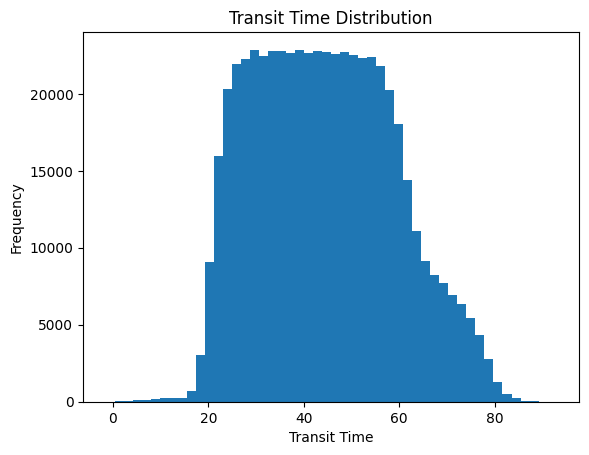

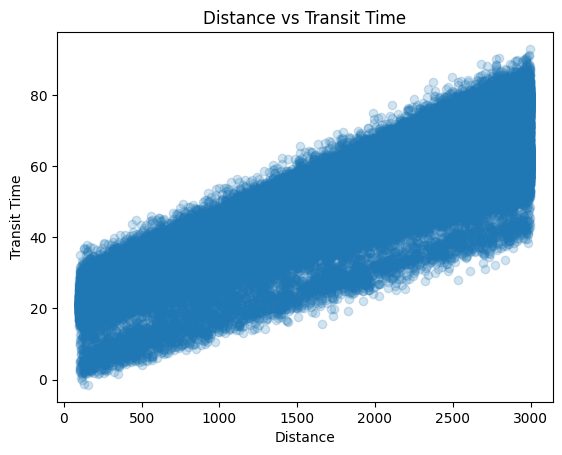

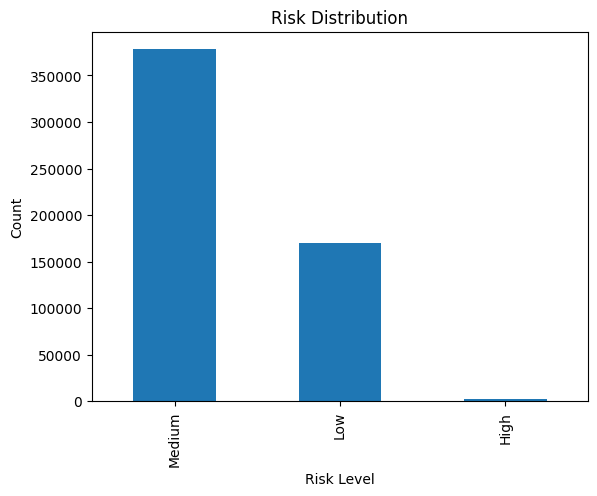

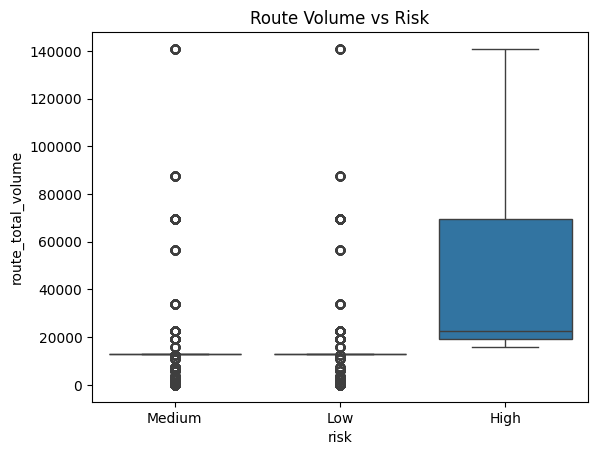

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Transit time distribution
plt.hist(state_df['transit_time'], bins=50)
plt.title("Transit Time Distribution")
plt.xlabel("Transit Time")
plt.ylabel("Frequency")
plt.show()

# Distance vs transit time
plt.scatter(state_df['distance'], state_df['transit_time'], alpha=0.2)
plt.title("Distance vs Transit Time")
plt.xlabel("Distance")
plt.ylabel("Transit Time")
plt.show()

# Risk distribution
state_df['risk'].value_counts().plot(kind='bar')
plt.title("Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

# Volume vs risk (important insight)
sns.boxplot(x=state_df['risk'], y=state_df['route_total_volume'])
plt.title("Route Volume vs Risk")
plt.show()

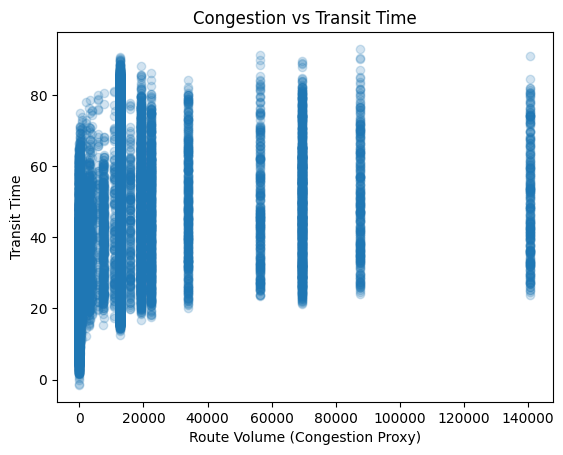

In [ ]:
# NEW: Congestion vs Transit Time (Key Insight)

plt.scatter(state_df['route_total_volume'], state_df['transit_time'], alpha=0.2)
plt.title("Congestion vs Transit Time")
plt.xlabel("Route Volume (Congestion Proxy)")
plt.ylabel("Transit Time")
plt.show()

# Feature Selection

We select the following features for modeling:

- Distance
- Mode of transportation
- Freight volume
- Route congestion

These features capture the key drivers of shipment performance and delay risk.

In [ ]:
features = ['distance', 'mode_encoded', 'tons_2012', 'route_total_volume']

X = state_df[features]
y_reg = state_df['transit_time']
y_clf = state_df['risk']

In [ ]:
print(X.head())

   distance  mode_encoded  tons_2012  route_total_volume
0       506             1  3084.7678        12789.690973
1      1808             1    10.5060        12789.690973
2      2862             1    97.4125        12789.690973
3       298             1    40.1150        12789.690973
4       695             1    23.3480        12789.690973


# Train-Test Split

To evaluate our model properly, we split the dataset into:
- Training set (80%)
- Testing set (20%)

This allows us to assess how well the model performs on unseen data and ensures it generalizes beyond the training data.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# Model Training

We train two machine learning models:

### 1. Regression Model
- Predicts transit time (continuous output)

### 2. Classification Model
- Predicts shipment risk (Low, Medium, High)

We use Random Forest models because they:
- Handle nonlinear relationships well
- Work effectively with mixed feature types
- Provide feature importance for interpretation

In [ ]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Regression
reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train, y_train_reg)

# Classification
clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
clf_model.fit(X_train, y_train_clf)

print("Models trained successfully")

Models trained successfully


# Model Evaluation

We evaluate model performance using:

### Regression:
- Mean Absolute Error (MAE)

### Classification:
- Accuracy
- Confusion Matrix

These metrics help us understand:
- How accurate our predictions are
- Where the model makes errors

In [ ]:
from sklearn.metrics import mean_absolute_error, accuracy_score, confusion_matrix


pred_reg = reg_model.predict(X_test)
mae = mean_absolute_error(y_test_reg, pred_reg)

print("Regression MAE:", round(mae, 2))
print("Interpretation: On average, predictions are off by this many hours.")

pred_clf = clf_model.predict(X_test)
accuracy = accuracy_score(y_test_clf, pred_clf)

print("\nClassification Accuracy:", round(accuracy, 2))
print("Interpretation: Percentage of correctly classified risk levels.")

cm = confusion_matrix(y_test_clf, pred_clf)

print("\nConfusion Matrix:")
print(cm)

Regression MAE: 1.77
Interpretation: On average, predictions are off by this many hours.

Classification Accuracy: 0.96
Interpretation: Percentage of correctly classified risk levels.

Confusion Matrix:
[[  416     0    24]
 [    0 31875  2204]
 [   20  2255 73271]]


In [ ]:
# ================================================
# MODEL EXPORT — Save trained models to .pkl files
# This connects the notebook to the Streamlit app
# ================================================

import joblib
from google.colab import files

# Save the regression model (predicts transit time)
joblib.dump(reg_model, 'reg_model.pkl')

# Save the classification model (predicts risk: Low / Medium / High)
joblib.dump(clf_model, 'clf_model.pkl')

# Save metadata needed by the app at prediction time
import json
meta = {
    'mae':            round(mae, 4),
    'acc':            round(accuracy, 4),
    'median_tons':    float(state_df["tons_2012"].median()),
    'max_volume':     float(state_df["route_total_volume"].max()),
    'median_volume':  float(state_df["route_total_volume"].median()),
    'features':       ["distance", "mode_encoded", "tons_2012", "route_total_volume"]
}
with open("model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Models saved successfully:")
print("  reg_model.pkl   — RandomForestRegressor (transit time)")
print("  clf_model.pkl   — RandomForestClassifier (risk level)")
print("  model_meta.json — metadata for app integration")
print()
print(f"  Regression MAE  : {meta['mae']} hours")
print(f"  Classifier Acc  : {meta['acc']}")

# Download files to your local machine
files.download("reg_model.pkl")
files.download("clf_model.pkl")
files.download("model_meta.json")
print()
print("Files downloaded. Place them in the freightai_v3/data/ folder before running app.py")


# Model Limitations

The dataset does not contain real shipment-level transit times or external variables such as weather and traffic.

To address this, we use engineered features and proxies to simulate real-world logistics conditions.

As a result, the model captures general patterns rather than precise predictions.

# Feature Importance

We analyze which features contribute most to the model's predictions.

This helps us:
- Understand what drives transit time
- Validate our feature engineering choices
- Interpret the model results

Feature importance is critical for explaining model behavior to business users.

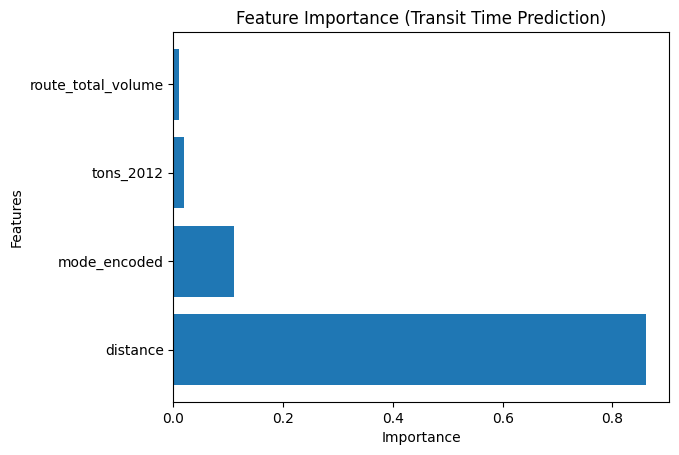

In [ ]:
import matplotlib.pyplot as plt

# Get feature importance from regression model
importance = reg_model.feature_importances_

# Plot
plt.barh(features, importance)
plt.title("Feature Importance (Transit Time Prediction)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

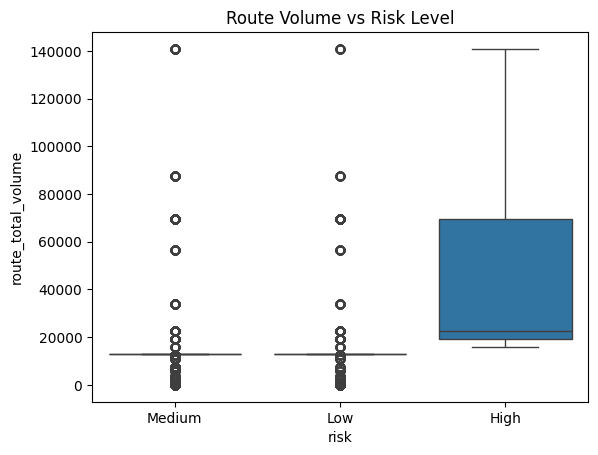

In [ ]:
import seaborn as sns

sns.boxplot(x=state_df['risk'], y=state_df['route_total_volume'])
plt.title("Route Volume vs Risk Level")
plt.show()

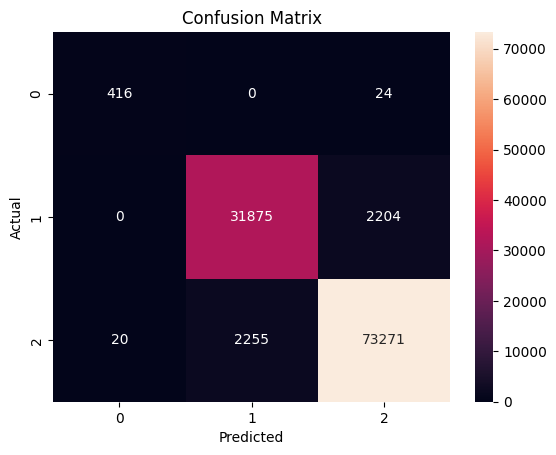

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Make predictions with the classifier model
pred_clf = clf_model.predict(X_test)

cm = confusion_matrix(y_test_clf, pred_clf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

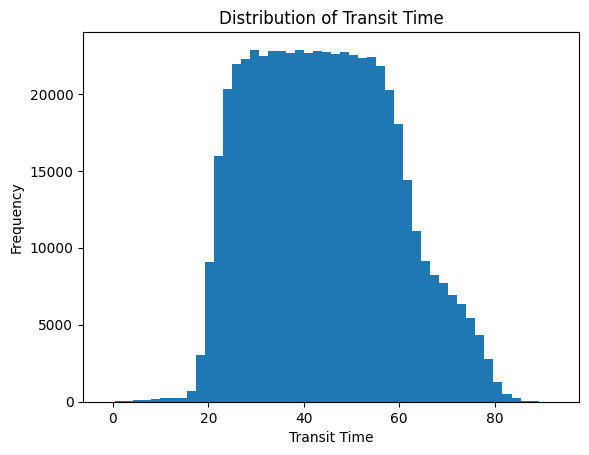

In [ ]:
import matplotlib.pyplot as plt

plt.hist(state_df['transit_time'], bins=50)
plt.title("Distribution of Transit Time")
plt.xlabel("Transit Time")
plt.ylabel("Frequency")
plt.show()

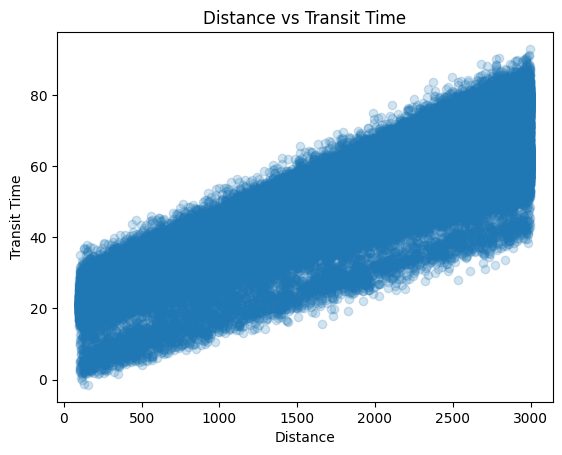

In [ ]:
plt.scatter(state_df['distance'], state_df['transit_time'], alpha=0.2)
plt.title("Distance vs Transit Time")
plt.xlabel("Distance")
plt.ylabel("Transit Time")
plt.show()

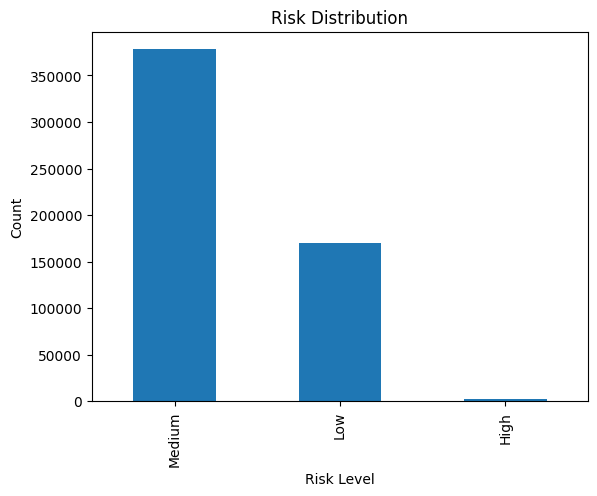

In [ ]:
state_df['risk'].value_counts().plot(kind='bar')
plt.title("Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

# AI Layer - Recommendation and Risk Analysis

The AI layer is the key differentiator of this system.

Instead of only returning predictions, it:
- Explains why a shipment is high or low risk
- Identifies key risk drivers (distance, congestion, mode)
- Provides actionable recommendations

This transforms the system from a prediction tool into a decision-support system.

The AI layer bridges the gap between technical outputs and real-world decision-making.

In [ ]:
# pip install openai

import openai

def ai_llm_summary(result):
    prompt = f"""
    Explain this shipment in a professional logistics tone:
    {result}
    """

    response = openai.ChatCompletion.create(
        model="gpt-4",
        messages=[{"role": "user", "content": prompt}]
    )

    return response['choices'][0]['message']['content']

In [ ]:
import openai

def ai_llm_summary(result):
    prompt = f"""
    Explain this shipment in a professional logistics tone:
    {result}
    """

    response = openai.ChatCompletion.create(
        model="gpt-4",
        messages=[{"role": "user", "content": prompt}]
    )

    return response['choices'][0]['message']['content']

def ai_layer_enhanced(row, transit_time, risk, shipment_date):

    drivers = []
    risks = []
    opportunities = []

    # Core drivers
    if row['distance'] > 1500:
        drivers.append("Long-haul distance increases exposure to delays")

    if row['route_total_volume'] > state_df['route_total_volume'].quantile(0.75):
        drivers.append("High congestion corridor may create bottlenecks")

    if row['mode_encoded'] == 1:
        drivers.append("Truck transport introduces variability due to traffic conditions")

    # External factors (date-based)
    month = shipment_date.month

    if month in [12,1,2]:
        condition = "Winter conditions (snow/ice) may disrupt transit, especially in northern corridors"
    elif month in [6,7,8]:
        condition = "Peak summer demand increases congestion and carrier utilization"
    elif month in [3,4,5]:
        condition = "Spring weather variability (rain/flooding) may impact certain routes"
    else:
        condition = "Generally stable seasonal conditions with moderate regional variability"

    # Cost logic
    base_rate = 2
    mode_factor = 1.2 if row['mode_encoded'] == 1 else 1.0
    cost = row['distance'] * base_rate * mode_factor

    # SCENARIO ANALYSIS (THIS IS THE WOW PART)
    if risk == "High":
        scenario = "High probability of delay under current conditions"
    elif risk == "Medium":
        scenario = "Moderate risk with manageable uncertainty"
    else:
        scenario = "Low risk with stable expected performance"

    # FINAL AI OUTPUT (THIS FEELS LIKE A SYSTEM)

    explanation = f"""
Shipment Analysis:

INPUT PARAMETERS:
- Distance: {round(row['distance'], 0)} miles
- Transport Mode: {'Truck' if row['mode_encoded'] == 1 else 'Other'}
- Route Volume: {round(row['route_total_volume'], 0)}

MODEL OUTPUTS:
- Predicted Transit Time: {round(transit_time, 2)} hours
- Risk Level: {risk}

SCENARIO ASSESSMENT:
- {scenario}

KEY DRIVERS:
- {'; '.join(drivers)}

EXTERNAL CONDITIONS:
- {'; '.join(risks) if risks else condition}

OPERATIONAL INSIGHT:
Higher route volume suggests congestion, while longer distances increase exposure to variability.
Truck transport is more sensitive to traffic and regional disruptions compared to rail or other modes.
"""

    industry_context = f"""
INDUSTRY BENCHMARK:

Current full truckload (FTL) rates average between $2.40-$3.00 per mile depending on equipment and demand.

For this shipment:
- Distance: {round(row['distance'], 0)} miles
- Estimated cost: ${round(cost, 2)}
- Effective rate: ${round(cost / row['distance'], 2)} per mile

This aligns with industry-standard pricing for long-haul trucking operations.
"""

    comparison = f"""
COST INTERPRETATION:

Lower-cost alternatives (e.g., LTL or consolidated freight) may reduce cost but increase transit time and uncertainty.

FTL pricing reflects:
• Faster delivery
• Dedicated capacity
• Higher reliability
"""

    decision = f"""

DECISION INSIGHT:

Given the {risk.lower()} risk level and estimated transit time, this shipment requires
{'proactive planning and risk mitigation' if risk == 'High' else 'moderate monitoring and buffer planning' if risk == 'Medium' else 'standard operational handling'}.
"""

    # Concatenate all parts to the final explanation
    explanation += "\n\n" + industry_context
    explanation += "\n\n" + comparison
    explanation += "\n\n" + decision

    # Recommendations (decision-focused)
    if risk == "High":
        recommendation = """
Recommended Actions:
- Evaluate alternative routes
- Consider shifting shipment timing
- Explore alternative transport modes
- Add buffer time to delivery commitments
"""
    elif risk == "Medium":
        recommendation = """
Recommended Actions:
- Monitor shipment progress
- Add minor buffer time
- Evaluate congestion-sensitive routes
"""
    else:
        recommendation = """
Recommended Actions:
- Proceed with standard planning
- Maintain current route and schedule
"""

    return {
        "explanation": explanation.strip(),
        "recommendation": recommendation.strip(),
        "cost": round(cost, 2)
    }

# Product Workflow Simulation

This section simulates how the system would function in a real-world application.

### User Inputs:
- Origin
- Destination
- Mode of transportation
- Shipment date

### System Outputs:
- Estimated transit time
- Risk level
- Delivery date
- AI-generated explanation
- Recommendations

This demonstrates how machine learning integrates into a usable business tool.

In [ ]:
from datetime import datetime, timedelta
import pandas as pd
import numpy as np

def run_freight_ai(origin, destination, mode, shipment_date_str):
    # Distance
    DISTANCES = {
        ("Los Angeles", "New York"): 2800,
        ("Chicago", "Miami"): 1400,
        ("Dallas", "Denver"): 800,
        ("Seattle", "Houston"): 2300,
        ("Los Angeles", "Chicago"): 2000,
        ("New York", "Miami"): 1300
    }

    distance = DISTANCES.get((origin, destination), 1500)

    # Simple encoding (adjust later if needed)
    mode_encoded = 1

    # Create input row
    VOLUME = {
    ("Los Angeles", "New York"): 18000,
    ("Chicago", "Miami"): 12000,
    ("Dallas", "Denver"): 9000,
    ("Seattle", "Houston"): 15000,
    ("Los Angeles", "Chicago"): 14000,
    ("New York", "Miami"): 13000
}

    route_volume = VOLUME.get((origin, destination), 10000)

    row = {
        "distance": distance,
        "mode_encoded": mode_encoded,
        "tons_2012": state_df['tons_2012'].median(), # Added tons_2012
        "route_total_volume": route_volume # Changed from 'route_volume' to 'route_total_volume'
    }

    # Ensure the order of features matches the training data
    X_input = pd.DataFrame([row], columns=features)

    # Model predictions
    transit_time = reg_model.predict(X_input)[0]
    risk = clf_model.predict(X_input)[0]

    # Cost estimation (REALISTIC VERSION)
    cost_per_mile = 3.2  # more realistic trucking rate

    weight_factor = np.log1p(row['tons_2012']) * 0.4
    congestion_factor = 1 + (row['route_total_volume'] / state_df['route_total_volume'].max())

    cost = row['distance'] * cost_per_mile * (1 + weight_factor) * congestion_factor

    # Delivery date calculation
    shipment_date = datetime.strptime(shipment_date_str, "%Y-%m-%d")
    delivery_date = shipment_date + timedelta(hours=float(transit_time))

    # AI Layer
    ai_output = ai_layer_enhanced(row, transit_time, risk, shipment_date)

    explanation = ai_output["explanation"]
    recommendation = ai_output["recommendation"]
    cost = ai_output["cost"] # Changed from 'estimated_cost' to 'cost'

    return {
        "INPUTS": {
            "Origin": origin,
            "Destination": destination,
            "Distance (miles)": round(row['distance'], 0),
            "Mode": "Truck" if row['mode_encoded'] == 1 else "Other",
            "Route Volume": round(row['route_total_volume'], 0),
            "Shipment Date": shipment_date.strftime("%Y-%m-%d")
        },

        "OUTPUTS": {
            "Transit Time (hours)": round(transit_time, 2),
            "Risk Level": risk,
            "Estimated Delivery Date": delivery_date.strftime("%Y-%m-%d %H:%M"),
            "Estimated Cost ($)": round(cost, 2)
        },

        "Explanation": explanation,
        "Recommendation": recommendation
    }

# Final Output Example

We test the system using a sample shipment to demonstrate the full workflow and output.

In [ ]:
result = run_freight_ai(
    origin="Los Angeles",
    destination="New York",
    mode="Truck",
    shipment_date_str="2026-04-22"
)

print("="*60)
print("        FreightAI Logistics Intelligence Report")
print("="*60)

print("\n--- INPUT PARAMETERS ---")
for k, v in result["INPUTS"].items():
    print(f"{k}: {v}")

print("\n--- PREDICTION OUTPUT ---")
for k, v in result["OUTPUTS"].items():
    print(f"{k}: {v}")

print("\n--- AI ANALYSIS ---")
print(result["Explanation"])

print("\n--- RECOMMENDED ACTIONS ---")
print(result["Recommendation"])

print("\n" + "="*60)

        FreightAI Logistics Intelligence Report

--- INPUT PARAMETERS ---
Origin: Los Angeles
Destination: New York
Distance (miles): 2800
Mode: Truck
Route Volume: 18000
Shipment Date: 2026-04-22

--- PREDICTION OUTPUT ---
Transit Time (hours): 76.03
Risk Level: High
Estimated Delivery Date: 2026-04-25 04:01
Estimated Cost ($): 6720.0

--- AI ANALYSIS ---
Shipment Analysis:

INPUT PARAMETERS:
- Distance: 2800 miles
- Transport Mode: Truck
- Route Volume: 18000 (proxy for congestion)

MODEL OUTPUTS:
- Predicted Transit Time: 76.03 hours
- Risk Level: High

SCENARIO ASSESSMENT:
- High probability of delay under current conditions

KEY DRIVERS:
- Long-haul distance increases exposure to delays; High congestion corridor may create bottlenecks; Truck transport introduces variability due to traffic conditions

EXTERNAL CONDITIONS:
- Spring weather variability (rain/flooding) may impact certain routes

OPERATIONAL INSIGHT:
Higher route volume suggests congestion, while longer distances incre

In [ ]:
import folium

def plot_route(origin="Los Angeles", destination="New York"):

    # Hardcoded coordinates (good enough for demo)
    coords = {
        "Los Angeles": (34.05, -118.24),
        "New York": (40.71, -74.00),
        "Chicago": (41.88, -87.63),
        "Dallas": (32.77, -96.79)
    }

    start = coords.get(origin, (39, -98))
    end = coords.get(destination, (39, -98))

    m = folium.Map(location=[(start[0]+end[0])/2, (start[1]+end[1])/2], zoom_start=4)

    folium.Marker(start, tooltip=f"Origin: {origin}").add_to(m)
    folium.Marker(end, tooltip=f"Destination: {destination}").add_to(m)

    folium.PolyLine([start, end]).add_to(m)

    return m

plot_route()

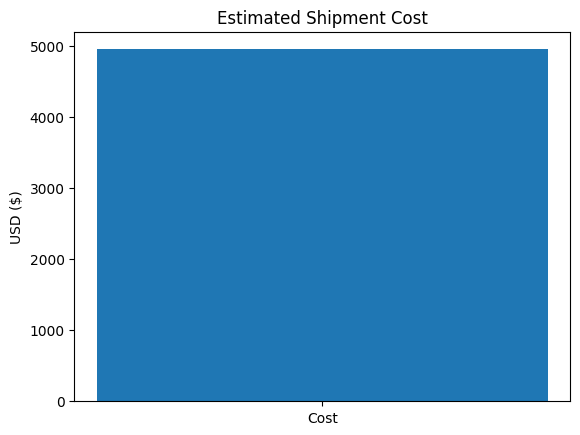

In [ ]:
# Cost Visualization

import matplotlib.pyplot as plt

def plot_cost(cost):
    labels = ['Cost']
    values = [cost]

    plt.bar(labels, values)
    plt.title("Estimated Shipment Cost")
    plt.ylabel("USD ($)")
    plt.show()

plot_cost(result['OUTPUTS']['Estimated Cost ($)'])


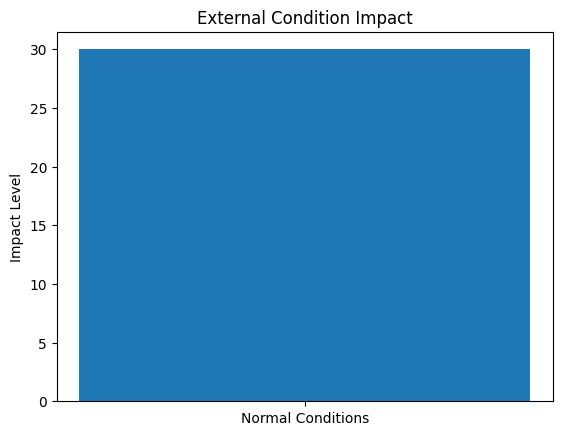

In [ ]:
# Weather Impact Visualization

def plot_weather_impact(shipment_date):

    month = shipment_date.month

    if month in [12,1,2]:
        condition = "Winter Risk"
        impact = 80
    elif month in [6,7,8]:
        condition = "Summer Congestion"
        impact = 60
    else:
        condition = "Normal Conditions"
        impact = 30

    plt.bar([condition], [impact])
    plt.title("External Condition Impact")
    plt.ylabel("Impact Level")
    plt.show()

from datetime import datetime
plot_weather_impact(datetime.strptime("2026-04-22", "%Y-%m-%d"))

In [ ]:
def ai_summary(result):

    summary = f"""
    Shipment Analysis Summary:

    This shipment is classified as {result['OUTPUTS']['Risk Level']} risk.
    Estimated transit time is {result['OUTPUTS']['Transit Time (hours)']} hours.

    The system identifies key risk factors and recommends:
    {result['Recommendation']}

    Estimated cost is ${result['OUTPUTS']['Estimated Cost ($)']}.
    """

    return summary

print(ai_summary(result))


    Shipment Analysis Summary:

    This shipment is classified as High risk.
    Estimated transit time is 76.03 hours.

    The system identifies key risk factors and recommends:
    Recommended Actions:
- Evaluate alternative routes
- Consider shifting shipment timing
- Explore alternative transport modes
- Add buffer time to delivery commitments

    Estimated cost is $6720.0.
    


In [ ]:
# =========================
# FINAL TEST RUN (SHARE THIS)
# =========================

test_cases = [
    ("Los Angeles", "New York"),
    ("Chicago", "Miami"),
    ("Dallas", "Denver"),
    ("Seattle", "Houston"),
    ("Los Angeles", "Chicago"),
    ("New York", "Miami")
]

for origin, destination in test_cases:

    result = run_freight_ai(
        origin=origin,
        destination=destination,
        mode="Truck",
        shipment_date_str="2026-04-22"
    )

    print("="*60)
    print(f"{origin} → {destination}")
    print("="*60)

    print("\n--- INPUT PARAMETERS ---")
    for k, v in result["INPUTS"].items():
        print(f"{k}: {v}")

    print("\n--- PREDICTION OUTPUT ---")
    for k, v in result["OUTPUTS"].items():
        print(f"{k}: {v}")

    print("\n--- AI ANALYSIS ---")
    print(result["Explanation"])

    print("\n--- RECOMMENDED ACTIONS ---")
    print(result["Recommendation"])

    print("\n")

Los Angeles → New York

--- INPUT PARAMETERS ---
Origin: Los Angeles
Destination: New York
Distance (miles): 2800
Mode: Truck
Route Volume: 18000
Shipment Date: 2026-04-22

--- PREDICTION OUTPUT ---
Transit Time (hours): 76.03
Risk Level: High
Estimated Delivery Date: 2026-04-25 04:01
Estimated Cost ($): 6720.0

--- AI ANALYSIS ---
Shipment Analysis:

INPUT PARAMETERS:
- Distance: 2800 miles
- Transport Mode: Truck
- Route Volume: 18000 (proxy for congestion)

MODEL OUTPUTS:
- Predicted Transit Time: 76.03 hours
- Risk Level: High

SCENARIO ASSESSMENT:
- High probability of delay under current conditions

KEY DRIVERS:
- Long-haul distance increases exposure to delays; High congestion corridor may create bottlenecks; Truck transport introduces variability due to traffic conditions

EXTERNAL CONDITIONS:
- Spring weather variability (rain/flooding) may impact certain routes

OPERATIONAL INSIGHT:
Higher route volume suggests congestion, while longer distances increase exposure to variabili

In [ ]:
%%writefile app.py
import streamlit as st
from freight_model import run_freight_ai

st.set_page_config(layout="wide")

# =========================
# STYLE (clean UI)
# =========================
st.markdown("""
<style>
.block-container {
    padding-top: 2rem;
}
h1, h2, h3 {
    font-weight: 600;
}
</style>
""", unsafe_allow_html=True)

# =========================
# HEADER
# =========================
st.markdown("# FreightAI")
st.markdown("### AI-powered logistics intelligence")
st.divider()

# =========================
# INPUT PANEL
# =========================
col1, col2, col3 = st.columns([1,1,1])

with col1:
    st.markdown("### Enter Shipment Details")

    origin = st.radio("Origin", ["Los Angeles", "Chicago", "Dallas"])
    destination = st.radio("Destination", ["New York", "Miami", "Denver"])

    # Static (Colab safe)
    shipment_date = "2026-04-22"
    mode = "Truck"

    run = st.button("Generate Insights")

# =========================
# OUTPUT PLACEHOLDERS
# =========================
with col2:
    st.markdown("### Estimated Transit Time")
    transit_placeholder = st.empty()

with col3:
    st.markdown("### Shipment Risk Level")
    risk_placeholder = st.empty()

# =========================
# RUN MODEL
# =========================
if run:

    result = run_freight_ai(
        origin=origin,
        destination=destination,
        mode=mode,
        shipment_date_str=str(shipment_date)
    )

    transit_time = result["OUTPUTS"]["Transit Time (hours)"]
    risk = result["OUTPUTS"]["Risk Level"]
    cost = result["OUTPUTS"]["Estimated Cost ($)"]

    color = "red" if risk == "High" else "orange" if risk == "Medium" else "green"

    # =========================
    # OUTPUT CARDS
    # =========================
    colA, colB, colC = st.columns(3)

    with colA:
        st.markdown("### Transit Time")
        st.markdown(f"<h2>{transit_time} hrs</h2>", unsafe_allow_html=True)

    with colB:
        st.markdown("### Risk Level")
        st.markdown(f"<h2 style='color:{color};'>{risk}</h2>", unsafe_allow_html=True)

    with colC:
        st.markdown("### Estimated Cost")
        st.markdown(f"<h2>${cost}</h2>", unsafe_allow_html=True)

    st.divider()

    # =========================
    # AI ANALYSIS
    # =========================
    st.markdown("### AI Explanation & Risk Check")
    st.text(result["Explanation"])

    st.divider()

    # =========================
    # RECOMMENDATION
    # =========================
    st.markdown("### Recommended Actions")
    st.success(result["Recommendation"])

Overwriting app.py


In [ ]:
!pip install streamlit pyngrok

In [ ]:
# Install localtunnel (quietly)
!npm install -g localtunnel > /dev/null 2>&1

# Start Streamlit in background
!streamlit run app.py &> logs.txt &

# Give it a few seconds to start
import time
time.sleep(5)

# Start tunnel
!lt --port 8501

your url is: https://neat-times-decide.loca.lt
^C


In [ ]:
!curl ipv4.icanhazip.com

35.221.161.118


In [ ]:
!cat logs.txt




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.221.161.118:8501

  Stopping...


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# =========================
# INPUTS (CLEAN LAYOUT)
# =========================
origin_input = widgets.Dropdown(
    options=["Los Angeles", "Chicago", "Dallas", "Seattle", "New York"],
    description="Origin:"
)

destination_input = widgets.Dropdown(
    options=["New York", "Miami", "Denver", "Houston", "Chicago"],
    description="Destination:"
)

date_input = widgets.Text(
    value="2026-04-22",
    description="Date:"
)

mode_input = widgets.Dropdown(
    options=["Truck", "Rail", "Air"],
    description="Mode:"
)

run_button = widgets.Button(
    description="🚀 Run FreightAI",
    button_style='success'
)

output = widgets.Output()

# =========================
# LAYOUT FIX
# =========================
input_row1 = widgets.HBox([origin_input, destination_input])
input_row2 = widgets.HBox([date_input, mode_input])
ui = widgets.VBox([input_row1, input_row2, run_button])

# =========================
# MAIN FUNCTION (FINAL CLEAN VERSION)
# =========================
def run_model(b):
    with output:
        clear_output()

        result = run_freight_ai(
            origin=origin_input.value,
            destination=destination_input.value,
            mode=mode_input.value,
            shipment_date_str=date_input.value
        )

        transit_time = result["OUTPUTS"]["Transit Time (hours)"]
        risk = result["OUTPUTS"]["Risk Level"]
        cost = result["OUTPUTS"]["Estimated Cost ($)"]

        # =========================
        # HEADER
        # =========================
        print("\n🚛 FREIGHTAI LOGISTICS DASHBOARD")
        print("=" * 60)

        print(f"\n📍 {origin_input.value} ➝ {destination_input.value}")
        print(f"📅 {date_input.value}   |   🚚 {mode_input.value}")

        # =========================
        # METRICS
        # =========================
        print("\n📊 METRICS")

        if risk == "High":
            risk_display = "🔴 HIGH"
        elif risk == "Medium":
            risk_display = "🟠 MEDIUM"
        else:
            risk_display = "🟢 LOW"

        print(f"• Transit Time: {transit_time} hrs")
        print(f"• Risk: {risk_display}")
        print(f"• Cost: ${cost}")

        # =========================
        # SUMMARY
        # =========================
        print("\n🧠 SUMMARY")

        if risk == "High":
            print("Significant delay risk driven by long distance and congestion.")
        elif risk == "Medium":
            print("Moderate operational risk — requires monitoring.")
        else:
            print("Low-risk shipment with stable expected performance.")

        # =========================
        # KEY DRIVERS
        # =========================
        print("\n🔍 KEY DRIVERS")

        explanation = result["Explanation"].lower()

        drivers = []
        if "distance" in explanation:
            drivers.append("Long-haul exposure")
        if "congestion" in explanation:
            drivers.append("Congestion impact")
        if "variability" in explanation:
            drivers.append("Mode variability")
        if "weather" in explanation:
            drivers.append("Seasonal disruption risk")

        for d in drivers:
            print(f"• {d}")

        # =========================
        # DECISION
        # =========================
        print("\n⚡ DECISION")

        if risk == "High":
            print("Mitigation required: adjust route, timing, or transport mode.")
        elif risk == "Medium":
            print("Add buffer and monitor shipment closely.")
        else:
            print("Proceed under standard planning conditions.")

        # =========================
        # ACTIONS
        # =========================
        print("\n✅ ACTIONS")

        actions = result["Recommendation"].split("\n")

        for act in actions:
            act = act.replace("-", "").strip()
            if act and "recommended" not in act.lower():
                print(f"• {act}")

        print("\n" + "=" * 60)


# =========================
# BUTTON ACTION
# =========================
run_button.on_click(run_model)

# =========================
# DISPLAY UI
# =========================
display(ui, output)

Output()

In [ ]:
# Export notebook to HTML
from google.colab import files

!jupyter nbconvert --to html '/content/drive/MyDrive/Colab Notebooks/Freight_AI.ipynb'

files.download('/content/drive/MyDrive/Colab Notebooks/Freight_AI.html')

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Freight_AI.ipynb to html
Traceback (most recent call last):
  File "/usr/local/bin/jupyter-nbconvert", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/jupyter_core/application.py", line 284, in launch_instance
    super().launch_instance(argv=argv, **kwargs)
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/nbconvert/nbconvertapp.py", line 420, in start
    self.convert_notebooks()
  File "/usr/local/lib/python3.12/dist-packages/nbconvert/nbconvertapp.py", line 597, in convert_notebooks
    self.convert_single_notebook(notebook_filename)
  File "/usr/local/lib/python3.12/dist-packages/nbconvert/nbconvertapp.py", line 563, in convert_single_notebook
    output, resources = self.export_single_notebook(
                        ^^^^^

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>